In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000
dzielnice = ["Mokotów", "Wola", "Śródmieście", "Praga-Południe", "Ursynów",
             "Bemowo", "Białołęka", "Targówek", "Bielany", "Ochota", "Wilanów"]
multiplikator_dzielnicy = {
    "Mokotów": 1.15, "Wola": 1.10, "Śródmieście": 1.40, "Praga-Południe": 0.90,
    "Ursynów": 1.00, "Bemowo": 0.95, "Białołęka": 0.85, "Targówek": 0.88,
    "Bielany": 0.95, "Ochota": 1.05, "Wilanów": 1.20
}

dzielnica = np.random.choice(dzielnice, n)
metraz = np.clip(np.random.normal(55, 22, n), 18, 180)
pokoje = np.clip(np.round(metraz / 18 + np.random.normal(0, 0.5, n)), 1, 6).astype(int)
pietro = np.random.randint(0, 12, n)
rok_budowy = np.random.choice(
    list(range(1950, 2025)),
    n,
    p=np.linspace(0.5, 2, 75) / np.linspace(0.5, 2, 75).sum()
)
ma_balkon = np.random.choice([True, False], n, p=[0.75, 0.25])
ma_miejsce_parkingowe = np.random.choice([True, False], n, p=[0.45, 0.55])
odleglosc_od_centrum = np.clip(np.random.gamma(2.5, 2.5, n), 0.5, 25)

# Cena za m² zależna od wielu czynników + szum
cena_za_m2 = (
    14000
    * np.array([multiplikator_dzielnicy[d] for d in dzielnica])
    * (1 + 0.005 * (rok_budowy - 1980))
    * (1 - 0.015 * odleglosc_od_centrum)
    * (1 + 0.05 * ma_balkon)
    * (1 + 0.08 * ma_miejsce_parkingowe)
    + np.random.normal(0, 1500, n)
)
cena = (cena_za_m2 * metraz).round(0)

df = pd.DataFrame({
    "id_oferty": range(10001, 10001 + n),
    "dzielnica": dzielnica,
    "metraz_m2": metraz.round(1),
    "liczba_pokoi": pokoje,
    "pietro": pietro,
    "rok_budowy": rok_budowy,
    "ma_balkon": ma_balkon,
    "ma_miejsce_parkingowe": ma_miejsce_parkingowe,
    "odleglosc_od_centrum_km": odleglosc_od_centrum.round(2),
    "cena_pln": cena
})

# Wstrzykujemy outliery i błędy
outlier_idx = np.random.choice(df.index, 30, replace=False)
df.loc[outlier_idx[:10], "cena_pln"] *= np.random.uniform(5, 12, 10)   # absurdalnie drogie (penthousy / błędy)
df.loc[outlier_idx[10:20], "cena_pln"] *= np.random.uniform(0.05, 0.2, 10)  # absurdalnie tanie (błędy / oszustwa)
df.loc[outlier_idx[20:25], "metraz_m2"] = np.random.uniform(300, 600, 5)   # gigantyczne metraże
df.loc[outlier_idx[25:30], "rok_budowy"] = np.random.choice([1800, 1850, 2050, 2099], 5)  # bzdurne daty

df.to_csv("mieszkania_warszawa.csv", index=False)
print(f"Wygenerowano plik 'mieszkania_warszawa.csv' — {len(df)} ofert")

Wygenerowano plik 'mieszkania_warszawa.csv' — 2000 ofert


SHAPE
(2000, 10)

INFO
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), str(1)
memory usage: 129.0 KB
None

DESCRIBE
          id_oferty    metraz_m2  liczba_pokoi       pietro   rok_budowy  \
count   2000.000000  2000.000000   2000.000000  2000.000000  2000.000000 

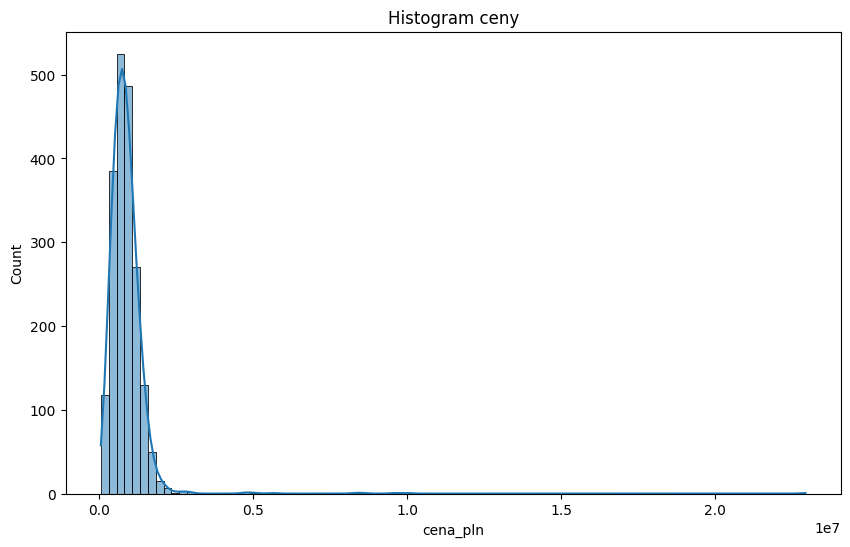

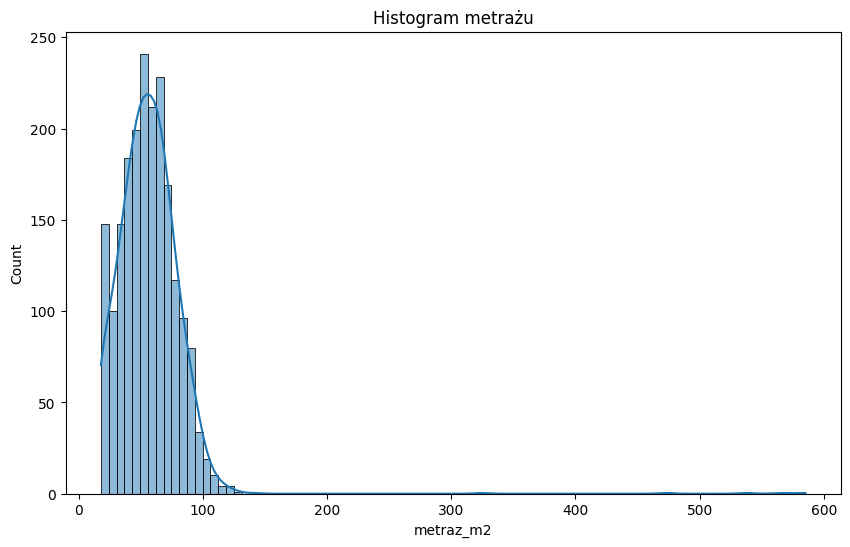

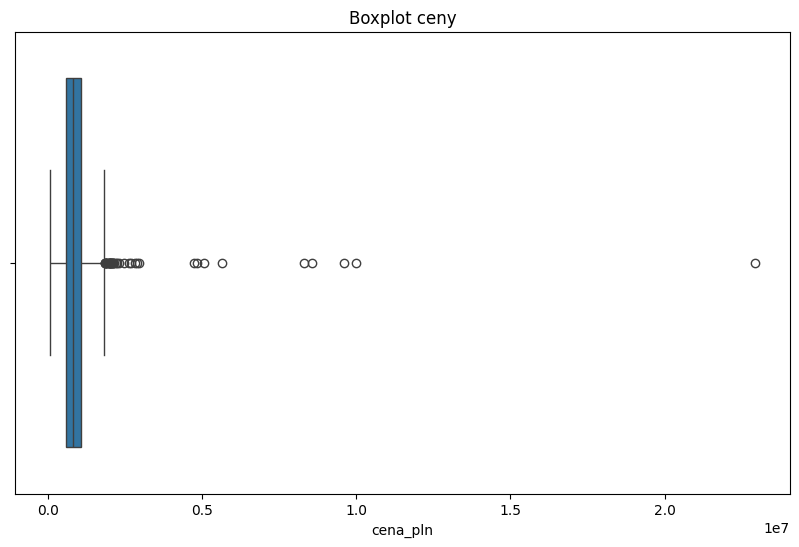

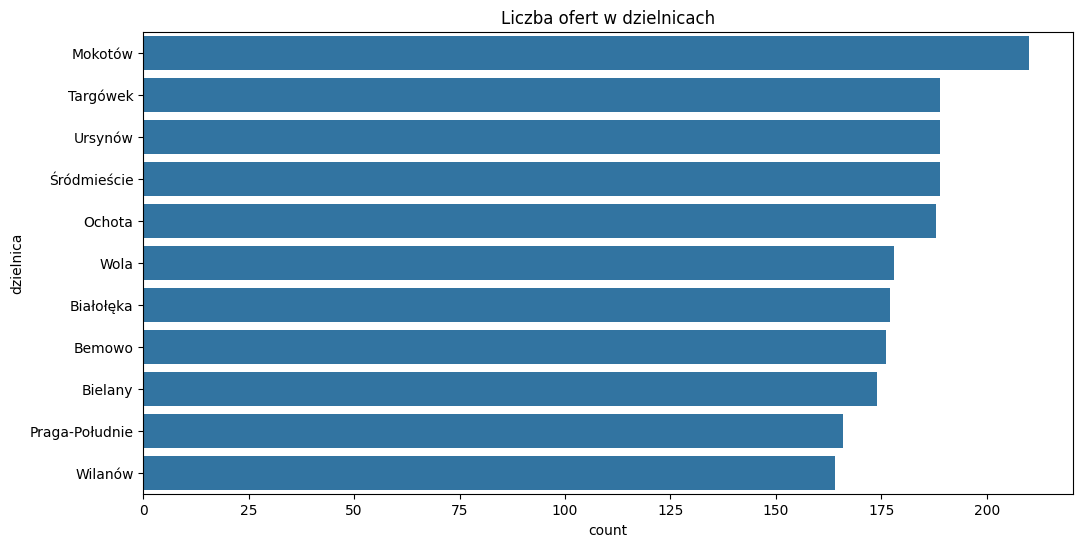

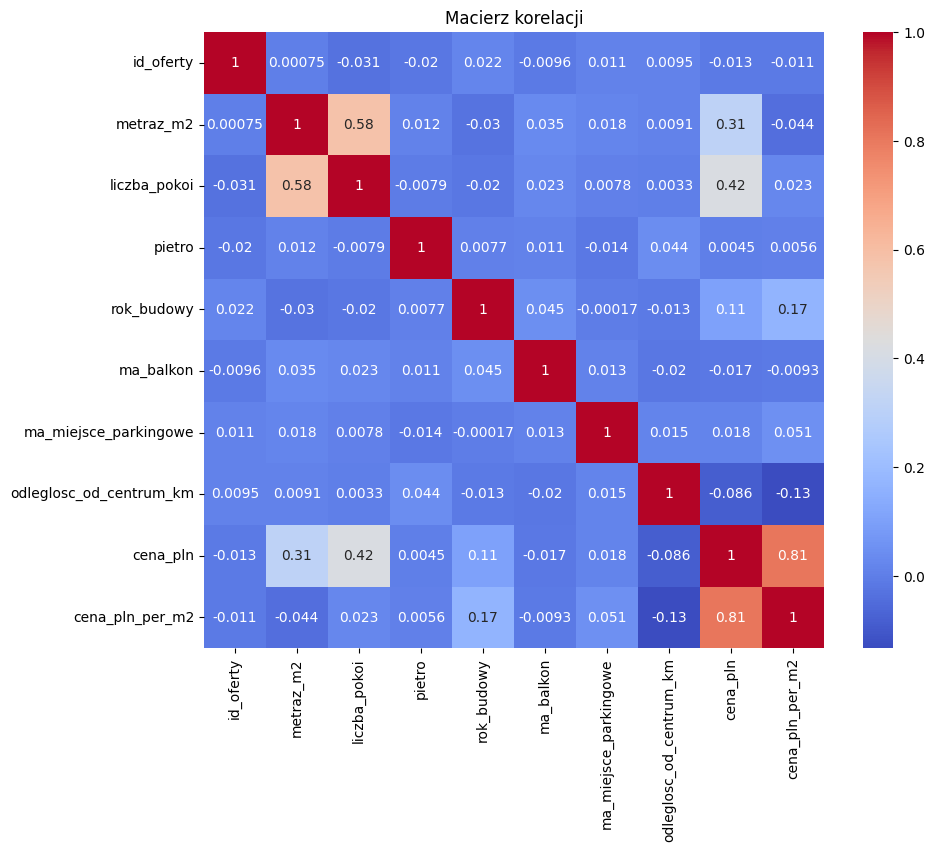


Korelacja z ceną:
cena_pln                   1.000000
cena_pln_per_m2            0.808618
liczba_pokoi               0.419491
metraz_m2                  0.310040
rok_budowy                 0.105799
ma_miejsce_parkingowe      0.017515
pietro                     0.004495
id_oferty                 -0.012569
ma_balkon                 -0.016987
odleglosc_od_centrum_km   -0.086266
Name: cena_pln, dtype: float64


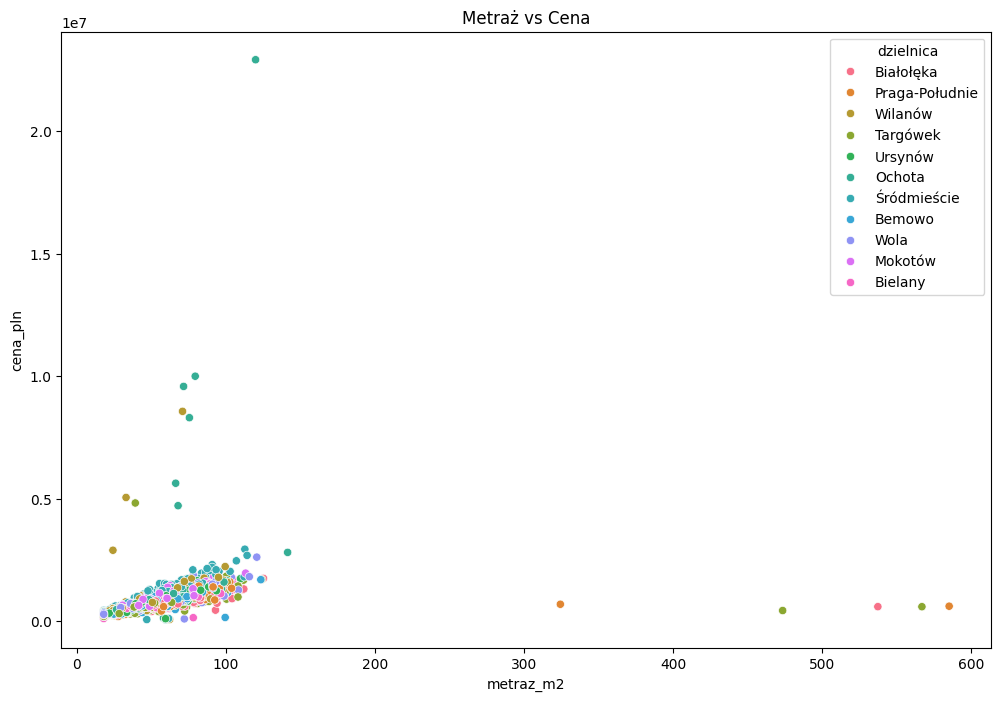

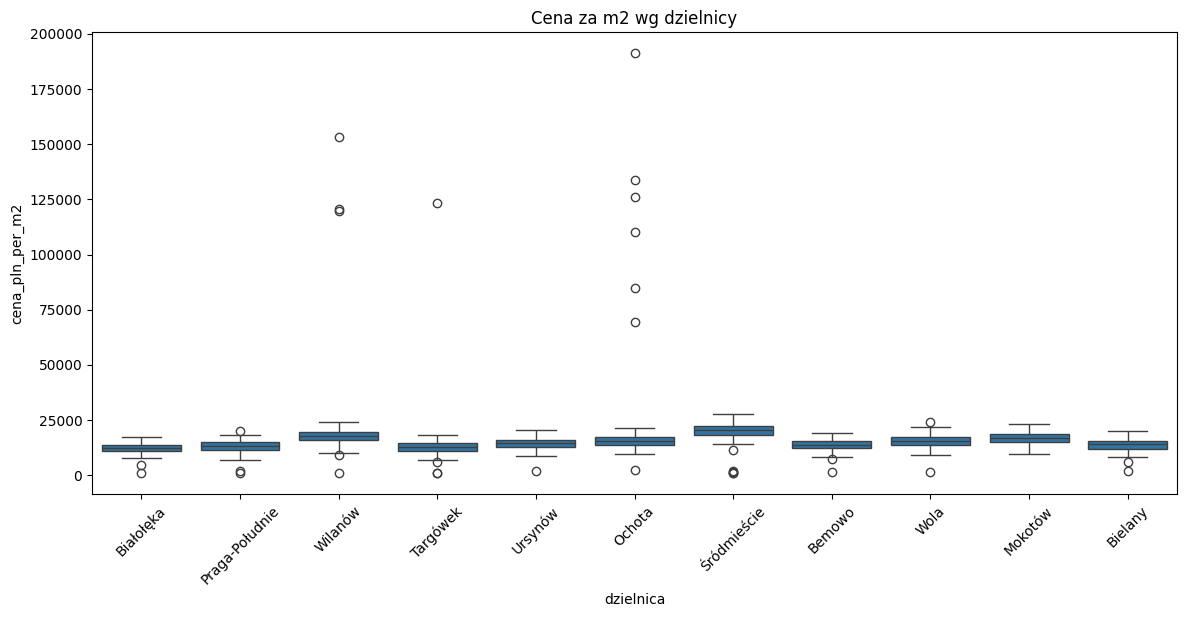


OUTLIERY IQR
39

OUTLIERY Z-SCORE
9

OUTLIERY MODIFIED Z
22

TOP 5 METRAŻY
      id_oferty   metraz_m2
1597      11598  585.187341
1845      11846  566.921693
53        10054  537.356930
1681      11682  473.491995
1050      11051  324.358377

BŁĘDNE LATA
      id_oferty  rok_budowy
237       10238        1850
557       10558        2050
635       10636        1800
1030      11031        2050
1954      11955        1800

SKEW PRZED:
15.858487305862825

SKEW PO LOG:
-0.24050400455486837


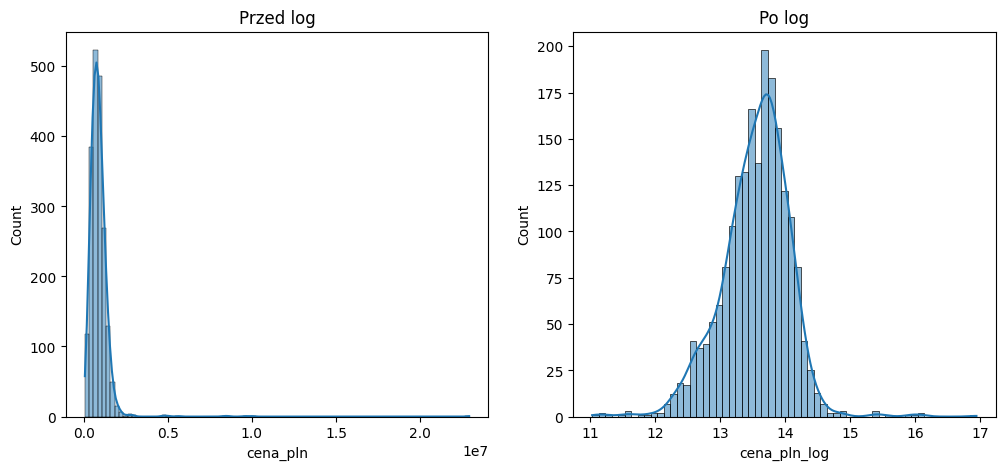


WNIOSKI:

1. Cena mieszkania silnie zależy od metrażu.
2. Śródmieście i Wilanów należą do najdroższych dzielnic.
3. W danych występują wyraźne outliery cenowe i metrażowe.
4. Logarytmowanie ceny zmniejsza skośność rozkładu.
5. Cena za m² jest lepszą miarą porównawczą niż cena całkowita.



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import zscore

df = pd.read_csv("mieszkania_warszawa.csv")

print("SHAPE")
print(df.shape)

print("\nINFO")
print(df.info())

print("\nDESCRIBE")
print(df.describe())

print("\nNULLS")
print(df.isnull().sum())

print("\nSTATYSTYKI CENY")

print("Średnia:", df["cena_pln"].mean())
print("Mediana:", df["cena_pln"].median())
print("Odchylenie:", df["cena_pln"].std())
print("Skewness:", df["cena_pln"].skew())
print("Kurtosis:", df["cena_pln"].kurtosis())

Q1 = df["metraz_m2"].quantile(0.25)
Q3 = df["metraz_m2"].quantile(0.75)
IQR = Q3 - Q1

print("\nMETRAŻ")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLICZBA OFERT W DZIELNICACH")
print(df["dzielnica"].value_counts())

df["cena_pln_per_m2"] = (
    df["cena_pln"] / df["metraz_m2"]
)

plt.figure(figsize=(10,6))
sns.histplot(df["cena_pln"], kde=True)
plt.title("Histogram ceny")
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df["metraz_m2"], kde=True)
plt.title("Histogram metrażu")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=df["cena_pln"])
plt.title("Boxplot ceny")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="dzielnica",
    order=df["dzielnica"].value_counts().index
)
plt.title("Liczba ofert w dzielnicach")
plt.show()

df_corr = df.copy()

df_corr["ma_balkon"] = (
    df_corr["ma_balkon"].astype(int)
)

df_corr["ma_miejsce_parkingowe"] = (
    df_corr["ma_miejsce_parkingowe"].astype(int)
)

corr = (
    df_corr
    .select_dtypes(include="number")
    .corr()
)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Macierz korelacji")
plt.show()

print("\nKorelacja z ceną:")
print(
    corr["cena_pln"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df,
    x="metraz_m2",
    y="cena_pln",
    hue="dzielnica"
)
plt.title("Metraż vs Cena")
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="dzielnica",
    y="cena_pln_per_m2"
)
plt.xticks(rotation=45)
plt.title("Cena za m2 wg dzielnicy")
plt.show()

Q1 = df["cena_pln"].quantile(0.25)
Q3 = df["cena_pln"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["cena_pln"] < lower)
    | (df["cena_pln"] > upper)
]

print("\nOUTLIERY IQR")
print(len(outliers_iqr))


z_scores = np.abs(
    zscore(df["cena_pln"])
)

outliers_z = df[z_scores > 3]

print("\nOUTLIERY Z-SCORE")
print(len(outliers_z))


median = df["cena_pln"].median()

mad = np.median(
    np.abs(df["cena_pln"] - median)
)

modified_z = (
    0.6745
    * (df["cena_pln"] - median)
    / mad
)

outliers_mod = df[
    np.abs(modified_z) > 3.5
]

print("\nOUTLIERY MODIFIED Z")
print(len(outliers_mod))


Q1_m = df["metraz_m2"].quantile(0.25)
Q3_m = df["metraz_m2"].quantile(0.75)

IQR_m = Q3_m - Q1_m

upper_m = Q3_m + 1.5 * IQR_m

metraz_outliers = df[
    df["metraz_m2"] > upper_m
]

print("\nTOP 5 METRAŻY")
print(
    df.nlargest(
        5,
        "metraz_m2"
    )[["id_oferty", "metraz_m2"]]
)

# Bzdurne daty

bad_years = df[
    (df["rok_budowy"] < 1900)
    | (df["rok_budowy"] > 2026)
]

print("\nBŁĘDNE LATA")
print(
    bad_years[
        ["id_oferty", "rok_budowy"]
    ]
)


df = df[
    (df["rok_budowy"] >= 1900)
    & (df["rok_budowy"] <= 2026)
]

p1 = df["cena_pln"].quantile(0.01)
p99 = df["cena_pln"].quantile(0.99)

df["cena_pln_capped"] = (
    df["cena_pln"]
    .clip(lower=p1, upper=p99)
)

df["cena_pln_log"] = (
    np.log1p(df["cena_pln"])
)

print("\nSKEW PRZED:")
print(df["cena_pln"].skew())

print("\nSKEW PO LOG:")
print(df["cena_pln_log"].skew())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["cena_pln"], kde=True)
plt.title("Przed log")

plt.subplot(1,2,2)
sns.histplot(df["cena_pln_log"], kde=True)
plt.title("Po log")

plt.show()


print("""
WNIOSKI:

1. Cena mieszkania silnie zależy od metrażu.
2. Śródmieście i Wilanów należą do najdroższych dzielnic.
3. W danych występują wyraźne outliery cenowe i metrażowe.
4. Logarytmowanie ceny zmniejsza skośność rozkładu.
5. Cena za m² jest lepszą miarą porównawczą niż cena całkowita.
""")